# ECG Multi-class Classification and Anomaly Detection on MIT-BIH (AAMI/de Chazal Standard)
## 1. Environment Setup and Dependencies
Import delle librerie e configurazione del seed riproducibile e del device hardware (GPU T4).

In [1]:
!pip install wfdb
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

import wfdb
from scipy.signal import butter, filtfilt
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility settings
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Segmentation constants
FS          = 360
HALF_WINDOW = 90
BEAT_LEN    = 2 * HALF_WINDOW

Using device: cuda


## 2. Data Loading and Mounting Google Drive
Montaggio del Drive e download del dataset PhysioNet mitdb.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/ECG_Project'
os.makedirs(DRIVE_PATH, exist_ok=True)
DATA_DIR = os.path.join(DRIVE_PATH, 'mitdb')

if not os.path.exists(DATA_DIR):
    print('Downloading mitdb from PhysioNet...')
    wfdb.dl_database('mitdb', DATA_DIR)
    print('Download completed.')
else:
    print(f'Dataset already present in {DATA_DIR}.')

Mounted at /content/drive
Dataset already present in /content/drive/MyDrive/ECG_Project/mitdb.


## 3. Standard de Chazal (2004) Dataset Partitioning
Definizione del mapping AAMI ed estrazione delle partizioni ufficiali DS1 (Train/Val) e DS2 (Test finale), escludendo i 4 record con pacemaker (102, 104, 107, 217).

In [3]:
def get_aami_category(symbol):
    """Maps MIT-BIH symbols to AAMI clinical categories."""
    mapping = {
        'N': 'Normal', 'L': 'Normal', 'R': 'Normal', 'e': 'Normal', 'j': 'Normal',
        'A': 'SVEB', 'a': 'SVEB', 'J': 'SVEB', 'S': 'SVEB',
        'V': 'VEB', 'E': 'VEB',
        'F': 'Fusion',
        '/': 'Paced', 'f': 'Paced', 'Q': 'Unknown'
    }
    return mapping.get(symbol, 'Other')

# Official de Chazal (2004) Record Distribution
DS1_RECORDS = ['101', '106', '108', '109', '112', '114', '115', '116', '118', '119',
               '122', '124', '201', '203', '205', '207', '208', '209', '215', '220', '223', '230']

DS2_RECORDS = ['100', '103', '105', '111', '113', '117', '121', '123', '200', '202',
               '210', '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234']

# Split DS1 into Train (80%) and Validation (20%) for early checkpointing
import random
random.seed(SEED)
shuffled_ds1 = DS1_RECORDS.copy()
random.shuffle(shuffled_ds1)

split_idx = int(0.8 * len(shuffled_ds1))
TRAIN_RECORDS = shuffled_ds1[:split_idx]
VAL_RECORDS   = shuffled_ds1[split_idx:]
TEST_RECORDS  = DS2_RECORDS

print(f'Train records (DS1 sub): {TRAIN_RECORDS}')
print(f'Val records (DS1 sub)  : {VAL_RECORDS}')
print(f'Test records (DS2)      : {TEST_RECORDS}')

Train records (DS1 sub): ['230', '114', '108', '207', '119', '201', '208', '220', '115', '203', '215', '205', '122', '106', '124', '112', '209']
Val records (DS1 sub)  : ['116', '118', '101', '109', '223']
Test records (DS2)      : ['100', '103', '105', '111', '113', '117', '121', '123', '200', '202', '210', '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234']


## 4. Signal Filtering and Segment Extraction
Funzioni di filtraggio Butterworth (0.5 - 45 Hz), segmentazione intorno al picco R e normalizzazione Z-score del singolo battito. La classe "Paced" viene ignorata poiché i record con pacemaker sono stati esclusi a monte.

In [4]:
def bandpass_filter(data, lowcut=0.5, highcut=45.0, fs=360, order=4):
    """Applies a Butterworth band-pass filter to the signal."""
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def load_records_filtered(record_list):
    """Filters signals and extracts Z-score normalized ECG segments around R-peaks."""
    x_data = []
    y_data = []
    label_map = {'Normal': 0, 'SVEB': 1, 'VEB': 2, 'Fusion': 3}

    for record_id in record_list:
        path = os.path.join(DATA_DIR, record_id)
        record = wfdb.rdrecord(path)
        signal = bandpass_filter(record.p_signal[:, 0])

        annotation = wfdb.rdann(path, 'atr')
        peaks = annotation.sample
        symbols = annotation.symbol

        for i in range(len(peaks)):
            category = get_aami_category(symbols[i])
            if category in label_map:
                start, end = peaks[i] - HALF_WINDOW, peaks[i] + HALF_WINDOW
                if start > 0 and end < len(signal):
                    segment = signal[start:end]
                    segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)
                    x_data.append(segment)
                    y_data.append(label_map[category])

    return np.array(x_data), np.array(y_data)

## 5. Building the Datasets
Estrazione fisica dei segmenti per Train, Val e Test dagli array NumPy.

In [5]:
print("Extracting training segments (filtered)...")
X_train, y_train = load_records_filtered(TRAIN_RECORDS)

print("Extracting validation segments (filtered)...")
X_val, y_val = load_records_filtered(VAL_RECORDS)

print("Extracting test segments (filtered)...")
X_test, y_test = load_records_filtered(TEST_RECORDS)

inv_label_map = {0: 'Normal (N)', 1: 'SVEB (S)', 2: 'VEB (V)', 3: 'Fusion (F)'}

def print_clean_dist(y, title):
    counts = Counter([int(i) for i in y])
    print(f"\n{title} Distribution:")
    for label, count in sorted(counts.items()):
        print(f" - {inv_label_map[label]}: {count}")

print_clean_dist(y_train, "Train")
print_clean_dist(y_val, "Validation")
print_clean_dist(y_test, "Test")

Extracting training segments (filtered)...
Extracting validation segments (filtered)...
Extracting test segments (filtered)...

Train Distribution:
 - Normal (N): 34995
 - SVEB (S): 771
 - VEB (V): 3152
 - Fusion (F): 398

Validation Distribution:
 - Normal (N): 10861
 - SVEB (S): 173
 - VEB (V): 636
 - Fusion (F): 16

Test Distribution:
 - Normal (N): 44246
 - SVEB (S): 1837
 - VEB (V): 3220
 - Fusion (F): 388


## 6. PyTorch Tensor Conversion and de Chazal Class Weighting
Conversione dei dati in tensori tridimensionali [Batch, Canali, Lunghezza] e calcolo della loss pesata secondo la regola di de Chazal: viene applicato un fattore correttivo di penalizzazione ($400 / N_k$) solo se la classe supera le 400 istanze.

In [6]:
print("Converting NumPy arrays to PyTorch Tensors...")
X_train_t = torch.FloatTensor(X_train).unsqueeze(1)
y_train_t = torch.LongTensor(y_train)

X_val_t = torch.FloatTensor(X_val).unsqueeze(1)
y_val_t = torch.LongTensor(y_val)

X_test_t = torch.FloatTensor(X_test).unsqueeze(1)
y_test_t = torch.LongTensor(y_test)

BATCH_SIZE_TRAIN = 128
BATCH_SIZE_EVAL = 256

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE_TRAIN, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE_EVAL, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE_EVAL, shuffle=False)

# de Chazal (2004) Class Weighting Formula
class_counts = np.bincount(y_train)
class_weights = np.zeros_like(class_counts, dtype=np.float32)

for i, count in enumerate(class_counts):
    if count > 400:
        class_weights[i] = 400.0 / count
    else:
        class_weights[i] = 1.0

class_weights = class_weights / class_weights.sum()
weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)

print(f"Class weights applied to the Cross Entropy Loss (de Chazal formulation): {class_weights}")

Converting NumPy arrays to PyTorch Tensors...
Class weights applied to the Cross Entropy Loss (de Chazal formulation): [0.00689755 0.3130735  0.07657984 0.60344917]


## 7. 1D-CNN Model Architecture
Definizione dell'architettura della rete convoluzionale monodimensionale a 4 uscite (le quattro classi AAMI principali stabili senza pacemaker).

In [7]:
class ECG1DCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(ECG1DCNN, self).__init__()

        # Block 1
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(32)

        # Block 2
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(64)

        # Block 3
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, stride=1, padding=2)
        self.bn3 = nn.BatchNorm1d(128)

        # Spatial pooling and regularization
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Global Average Pooling
        x = torch.mean(x, dim=2)
        x = self.dropout(x)
        return self.fc(x)

model = ECG1DCNN(num_classes=4).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

ECG1DCNN(
  (conv1): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)


## 8. Model Training with Model Checkpoint (Early Stopping Meccanico)
Loop di addestramento su 15 epoche. Per evitare il problema di overfitting evidente nell'esecuzione precedente, salviamo lo stato del modello (best_model.pth) soltanto quando si registra un reale miglioramento della val_loss.

In [8]:
EPOCHS = 15
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')

print("Starting training process with model checkpointing...")
for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    running_train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)

    # Validation Phase
    model.eval()
    running_val_loss = 0.0
    correct_predictions = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_predictions += torch.sum(preds == labels.data)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_predictions.double() / len(val_loader.dataset)

    # Checkpoint evaluation to store weights on minimum validation loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"--> Saved best model checkpoint at epoch {epoch+1}")

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc.item())

    print(f"Epoch {epoch+1}/{EPOCHS} -> Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")

Starting training process with model checkpointing...
--> Saved best model checkpoint at epoch 1
Epoch 1/15 -> Train Loss: 0.6952 | Val Loss: 1.3240 | Val Acc: 39.58%
Epoch 2/15 -> Train Loss: 0.4081 | Val Loss: 1.7594 | Val Acc: 28.54%
Epoch 3/15 -> Train Loss: 0.3402 | Val Loss: 1.6016 | Val Acc: 39.20%
Epoch 4/15 -> Train Loss: 0.2910 | Val Loss: 2.2810 | Val Acc: 48.21%
Epoch 5/15 -> Train Loss: 0.2799 | Val Loss: 2.5688 | Val Acc: 39.79%
Epoch 6/15 -> Train Loss: 0.2822 | Val Loss: 2.6022 | Val Acc: 40.39%
Epoch 7/15 -> Train Loss: 0.2484 | Val Loss: 2.3587 | Val Acc: 47.53%
Epoch 8/15 -> Train Loss: 0.2138 | Val Loss: 2.6315 | Val Acc: 42.91%
Epoch 9/15 -> Train Loss: 0.2316 | Val Loss: 2.7189 | Val Acc: 39.02%
Epoch 10/15 -> Train Loss: 0.2193 | Val Loss: 2.3045 | Val Acc: 42.55%
Epoch 11/15 -> Train Loss: 0.2118 | Val Loss: 1.9891 | Val Acc: 53.30%
Epoch 12/15 -> Train Loss: 0.1984 | Val Loss: 2.5206 | Val Acc: 32.48%
Epoch 13/15 -> Train Loss: 0.1983 | Val Loss: 2.1457 | Val A

## 9. Evaluation on DS2 Independent Test Set
Caricamento dei pesi ottimali dal checkpoint salvato, inferenza sul set di test indipendente DS2 (completamente separato dall'addestramento) e output grafico di report e matrice di confusione a 4 classi.


--- CLASSIFICATION & ANOMALY DETECTION REPORT (AAMI/DE CHAZAL STANDARDS) ---
              precision    recall  f1-score   support

  Normal (N)       0.93      0.67      0.78     44246
    SVEB (S)       0.05      0.03      0.04      1837
     VEB (V)       0.85      0.76      0.80      3220
  Fusion (F)       0.00      0.10      0.01       388

    accuracy                           0.65     49691
   macro avg       0.46      0.39      0.41     49691
weighted avg       0.89      0.65      0.75     49691



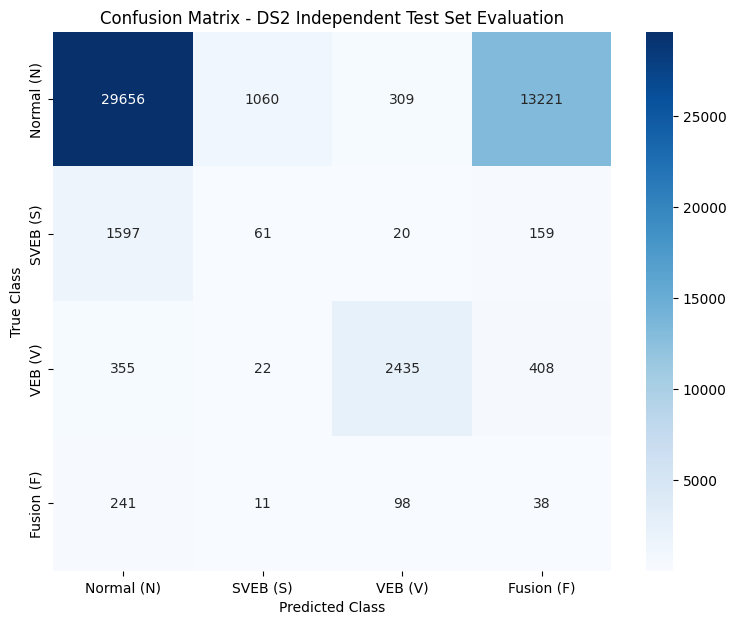

In [9]:
model.eval()
all_preds = []
all_labels = []

# Reload optimal checkpoint prior to test evaluation
model.load_state_dict(torch.load('best_model.pth'))

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Evaluation metric assessment on 4 core categories
target_names = ['Normal (N)', 'SVEB (S)', 'VEB (V)', 'Fusion (F)']
print("\n--- CLASSIFICATION & ANOMALY DETECTION REPORT (AAMI/DE CHAZAL STANDARDS) ---")
print(classification_report(all_labels, all_preds, target_names=target_names))

# Confusion Matrix rendering
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - DS2 Independent Test Set Evaluation')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()